In [4]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import sqlite3

conn = sqlite3.connect('/content/drive/MyDrive/churn-prediction-project/churn.db')
# This will list all tables in the database so you can find the correct table name.
df = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(df)
conn.close()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Empty DataFrame
Columns: [name]
Index: []


In [6]:
import kagglehub
import pandas as pd
import sqlite3
import os

# Re-download the dataset (fast, it's cached)
path = kagglehub.dataset_download("yeanzc/telco-customer-churn-ibm-dataset")
files = os.listdir(path)
print("Files found:", files)

# Load the Excel file (adjust filename below if different from what prints above)
df = pd.read_excel(os.path.join(path, files[0]))
print("Loaded", df.shape[0], "rows")

# Save into churn.db
conn = sqlite3.connect('/content/drive/MyDrive/churn-prediction-project/churn.db')
df.to_sql('customers', conn, if_exists='replace', index=False)
conn.commit()

# Verify it worked
check = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print(check)

Using Colab cache for faster access to the 'telco-customer-churn-ibm-dataset' dataset.
Files found: ['Telco_customer_churn.xlsx']
Loaded 7043 rows
        name
0  customers


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df.isnull().sum()

,0
CustomerID,0
Count,0
Country,0
State,0
City,0
Zip Code,0
Lat Long,0
Latitude,0
Longitude,0
Gender,0


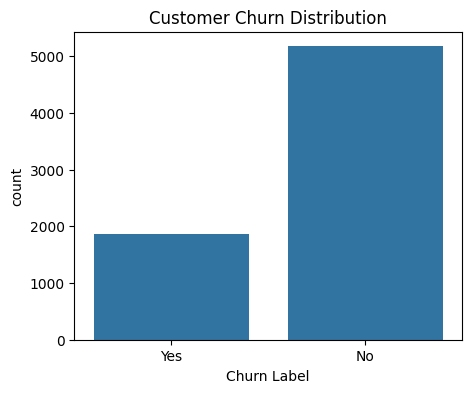

In [9]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='Churn Label')
plt.title('Customer Churn Distribution')
plt.show()

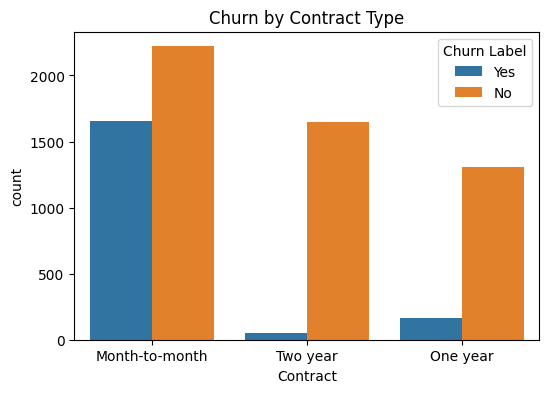

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='Contract', hue='Churn Label')
plt.title('Churn by Contract Type')
plt.show()

In [11]:
df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']].describe()

,Tenure Months,Monthly Charges,CLTV
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,4400.295755
std,24.559481,30.090047,1183.057152
min,0.000000,18.250000,2003.000000
25%,9.000000,35.500000,3469.000000
50%,29.000000,70.350000,4527.000000
75%,55.000000,89.850000,5380.500000
max,72.000000,118.750000,6500.000000


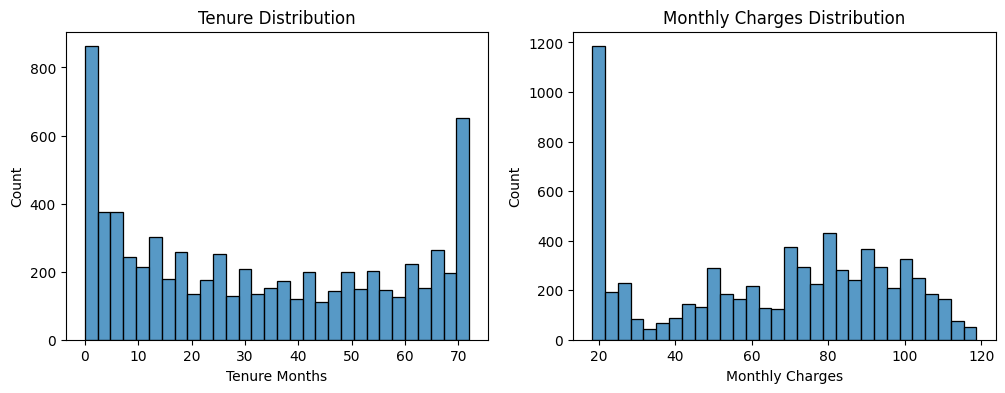

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.histplot(df['Tenure Months'], bins=30, ax=axes[0])
axes[0].set_title('Tenure Distribution')

sns.histplot(df['Monthly Charges'], bins=30, ax=axes[1])
axes[1].set_title('Monthly Charges Distribution')
plt.show()

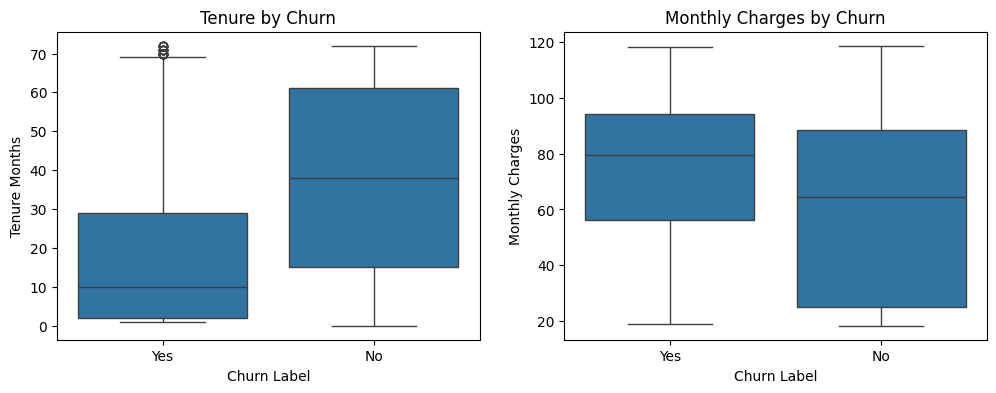

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
sns.boxplot(data=df, x='Churn Label', y='Tenure Months', ax=axes[0])
axes[0].set_title('Tenure by Churn')

sns.boxplot(data=df, x='Churn Label', y='Monthly Charges', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn')
plt.show()

In [14]:
from scipy import stats

churned = df[df['Churn Label'] == 'Yes']['Tenure Months']
retained = df[df['Churn Label'] == 'No']['Tenure Months']

t_stat, p_value = stats.ttest_ind(churned, retained)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_value:.5f}")

T-statistic: -31.580, P-value: 0.00000


In [16]:
#Chi-square test: does Contract type affect churn
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df['Contract'], df['Churn Label'])
chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"Chi-square statistic: {chi2:.3f}, P-value: {p}")
print(contingency_table)

Chi-square statistic: 1184.597, P-value: 5.863038300673391e-258
Churn Label       No   Yes
Contract                  
Month-to-month  2220  1655
One year        1307   166
Two year        1647    48


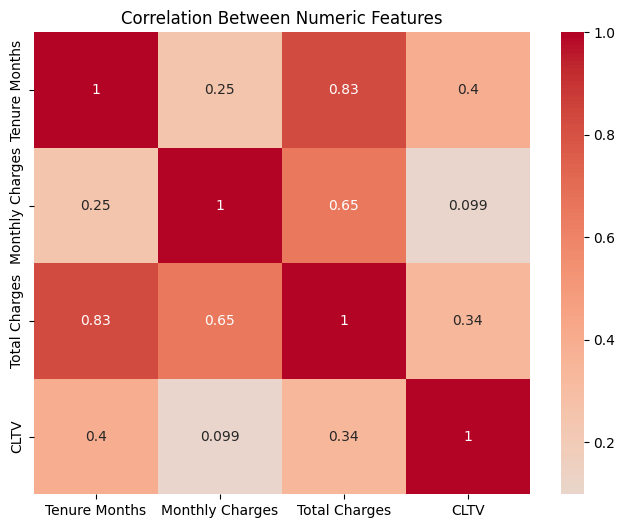

In [19]:
plt.figure(figsize=(8,6))
numeric_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV']
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features')
plt.show()